# Novelty Aspect — Dysbiosis ↔ Hippo-Activated CRC Tumors (Overlap + Direction + Enrichment)

## What we are testing (core idea)
If dysbiosis is linked to colorectal cancer progression, then genes altered in IBD (dysbiosis/inflammation)
should overlap with genes associated with Hippo/YAP activation in CRC tumors.

## Inputs (must exist from previous notebooks)
IBD:
- `results/de/ibd/IBD_DEG_IBD_vs_Control.csv`

TCGA:
- `results/de/tcga/TCGA_DEG_HippoHigh_vs_HippoLow.csv`

Outputs:
- overlap tables (same direction / opposite direction)
- a "core signature" list
- simple visualizations
- enrichment results (optional)


In [1]:
from google.colab import drive
drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/Colon_cancer_project"

IBD_DEG  = f"{BASE}/results/de/ibd/IBD_DEG_IBD_vs_Control.csv"
TCGA_DEG = f"{BASE}/results/de/tcga/TCGA_DEG_HippoHigh_vs_HippoLow.csv"

# optional for visualization
IBD_LOG  = f"{BASE}/data_processed/ibd/ibd_log2_tpm.csv"
TCGA_LOG = f"{BASE}/data_processed/tcga/tcga_log2_rsem.csv"

OUT = f"{BASE}/results/novelty"
FIG = f"{BASE}/results/figures/novelty"

import os
os.makedirs(OUT, exist_ok=True)
os.makedirs(FIG, exist_ok=True)

print("IBD DEG :", IBD_DEG)
print("TCGA DEG:", TCGA_DEG)


Mounted at /content/drive
IBD DEG : /content/drive/MyDrive/Colon_cancer_project/results/de/ibd/IBD_DEG_IBD_vs_Control.csv
TCGA DEG: /content/drive/MyDrive/Colon_cancer_project/results/de/tcga/TCGA_DEG_HippoHigh_vs_HippoLow.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#load tables and sanity checks

ibd = pd.read_csv(IBD_DEG)
tcga = pd.read_csv(TCGA_DEG)

print("IBD DEG shape:", ibd.shape)
print("TCGA DEG shape:", tcga.shape)

print("IBD columns:", ibd.columns.tolist())
print("TCGA columns:", tcga.columns.tolist())

# Expected columns:
# IBD: gene, logFC_IBD_minus_Control, padj_fdr
# TCGA: gene, logFC_Hippo_high_minus_Hippo_low, padj_fdr

display(ibd.head(3))
display(tcga.head(3))


IBD DEG shape: (57193, 9)
TCGA DEG shape: (20511, 6)
IBD columns: ['gene', 'mean_IBD', 'mean_Control', 'logFC_IBD_minus_Control', 'pval', 'padj_fdr', 'var_IBD', 'var_Control', 'valid_var']
TCGA columns: ['gene', 'mean_Hippo_high', 'mean_Hippo_low', 'logFC_Hippo_high_minus_Hippo_low', 'pval', 'padj_fdr']


,gene,mean_IBD,mean_Control,logFC_IBD_minus_Control,pval,padj_fdr,var_IBD,var_Control,valid_var
0,CTXN1,0.489287,0.039712,0.449576,2.501936e-12,1.153092e-07,0.094302,0.003835,True
1,PLPBP,4.822146,5.318890,-0.496744,1.268496e-11,2.923121e-07,0.084293,0.007565,True
2,CS,6.525292,7.040912,-0.515620,7.534646e-11,1.157523e-06,0.109758,0.009157,True


,gene,mean_Hippo_high,mean_Hippo_low,logFC_Hippo_high_minus_Hippo_low,pval,padj_fdr
0,CYR61,11.390036,8.705280,2.684756,6.636470e-73,1.324308e-68
1,CTGF,12.135373,9.930079,2.205294,6.049885e-66,6.036273e-62
2,KCNE4,7.471083,5.086596,2.384487,3.363832e-61,2.237509e-57


### Step-wise Summary of the Code

1. **Import libraries**

   * Imports `pandas` for data handling.
   * Imports `numpy` for numerical operations.
   * Imports `matplotlib.pyplot` for plotting.

2. **Load differential expression (DEG) datasets**

   * Reads the IBD DEG file into a DataFrame `ibd` using `pd.read_csv(IBD_DEG)`.
   * Reads the TCGA DEG file into a DataFrame `tcga` using `pd.read_csv(TCGA_DEG)`.

3. **Check dataset dimensions**

   * Prints the shape (rows × columns) of both datasets to verify successful loading.

4. **Inspect column structure**

   * Prints column names of both DataFrames to confirm expected schema.

5. **Document expected columns (comment)**

   * IBD expected columns: `gene`, `logFC_IBD_minus_Control`, `padj_fdr`.
   * TCGA expected columns: `gene`, `logFC_Hippo_high_minus_Hippo_low`, `padj_fdr`.

6. **Preview data**

   * Displays the first 3 rows of both datasets for quick sanity check.

---

### One-line Summary

The code loads IBD and TCGA DEG datasets, verifies their structure and dimensions, and previews initial rows for validation.


Filter Significant DEGs

In [3]:
def filter_deg(df, logfc_col, fdr_col="padj_fdr", fdr=0.05, abs_logfc=0.5):
    df = df.copy()
    df[fdr_col] = pd.to_numeric(df[fdr_col], errors="coerce").fillna(1.0)
    df[logfc_col] = pd.to_numeric(df[logfc_col], errors="coerce")
    keep = (df[fdr_col] < fdr) & (df[logfc_col].abs() >= abs_logfc)
    return df.loc[keep].copy()

IBD_LOGFC  = "logFC_IBD_minus_Control"
TCGA_LOGFC = "logFC_Hippo_high_minus_Hippo_low"

ibd_sig  = filter_deg(ibd,  IBD_LOGFC,  fdr=0.05, abs_logfc=0.5)
tcga_sig = filter_deg(tcga, TCGA_LOGFC, fdr=0.05, abs_logfc=0.5)

print("IBD sig :", ibd_sig.shape)
print("TCGA sig:", tcga_sig.shape)

ibd_sig.to_csv(f"{OUT}/IBD_sig_genes.csv", index=False)
tcga_sig.to_csv(f"{OUT}/TCGA_sig_genes.csv", index=False)


IBD sig : (891, 9)
TCGA sig: (4824, 6)


### Step-wise Summary of the Code

1. **Define DEG filtering function (`filter_deg`)**

   * Takes a DataFrame, log fold-change column name, FDR column name (default `"padj_fdr"`), FDR threshold (default `0.05`), and minimum absolute logFC (default `0.5`).
   * Creates a copy of the DataFrame to avoid modifying the original.
   * Converts FDR column to numeric; invalid values are coerced to `NaN` and replaced with `1.0`.
   * Converts logFC column to numeric (invalid values become `NaN`).
   * Creates a boolean mask selecting rows where:

     * `FDR < 0.05`, and
     * `|logFC| ≥ 0.5`.
   * Returns a filtered copy of the DataFrame containing only significant genes.

2. **Define logFC column names**

   * `IBD_LOGFC` → `"logFC_IBD_minus_Control"`
   * `TCGA_LOGFC` → `"logFC_Hippo_high_minus_Hippo_low"`

3. **Apply filtering to both datasets**

   * Filters `ibd` dataset → `ibd_sig`.
   * Filters `tcga` dataset → `tcga_sig`.

4. **Check filtered dataset dimensions**

   * Prints the shape (rows × columns) of significant genes in both datasets.

5. **Export filtered results**

   * Saves significant IBD genes to `IBD_sig_genes.csv`.
   * Saves significant TCGA genes to `TCGA_sig_genes.csv`.
   * Files are saved in the specified output directory `OUT`.

---

### One-line Summary

The code filters IBD and TCGA DEG datasets for significant genes (FDR < 0.05 and |logFC| ≥ 0.5) and saves the filtered results as CSV files.


Overlap identification between conditions (same or opposite direction)

In [4]:
m = ibd_sig[["gene", IBD_LOGFC, "padj_fdr"]].merge(
    tcga_sig[["gene", TCGA_LOGFC, "padj_fdr"]],
    on="gene",
    suffixes=("_IBD", "_TCGA"),
    how="inner"
)

m["direction_IBD"]  = np.sign(m[IBD_LOGFC])
m["direction_TCGA"] = np.sign(m[TCGA_LOGFC])

m["direction_match"] = np.where(m["direction_IBD"] == m["direction_TCGA"],
                                "same_direction", "opposite_direction")

print("Total overlap:", m.shape[0])
print(m["direction_match"].value_counts())

m.to_csv(f"{OUT}/overlap_IBD_TCGA_all.csv", index=False)
m[m["direction_match"]=="same_direction"].to_csv(f"{OUT}/overlap_IBD_TCGA_same_direction.csv", index=False)
m[m["direction_match"]=="opposite_direction"].to_csv(f"{OUT}/overlap_IBD_TCGA_opposite_direction.csv", index=False)

display(m.head(10))


Total overlap: 147
direction_match
same_direction        120
opposite_direction     27
Name: count, dtype: int64


,gene,logFC_IBD_minus_Control,padj_fdr_IBD,logFC_Hippo_high_minus_Hippo_low,padj_fdr_TCGA,direction_IBD,direction_TCGA,direction_match
0,POMC,0.530186,0.000005,1.261801,2.493330e-17,1.0,1.0,same_direction
1,CD70,0.802533,0.000012,1.052515,3.089295e-07,1.0,1.0,same_direction
2,TNFRSF4,1.462282,0.000013,1.129948,6.429214e-17,1.0,1.0,same_direction
3,PTP4A3,1.367909,0.000085,0.584400,3.116054e-04,1.0,1.0,same_direction
4,UBTD1,0.967413,0.000120,1.066508,6.093768e-25,1.0,1.0,same_direction
5,CLRN3,-0.615498,0.000123,-0.663325,2.607743e-09,-1.0,-1.0,same_direction
6,IGFALS,1.058137,0.000169,-0.949764,1.988118e-03,1.0,-1.0,opposite_direction
7,SOX18,1.462494,0.000204,0.820106,1.598924e-11,1.0,1.0,same_direction
8,IL11,1.320844,0.000217,2.046087,8.053130e-18,1.0,1.0,same_direction
9,TUBB3,1.119281,0.000247,0.541986,6.075002e-05,1.0,1.0,same_direction


### Step-wise Summary of the Code

1. **Merge significant gene datasets**

   * Selects relevant columns from `ibd_sig` (`gene`, IBD logFC, `padj_fdr`).
   * Selects relevant columns from `tcga_sig` (`gene`, TCGA logFC, `padj_fdr`).
   * Performs an **inner merge** on `"gene"` to retain only overlapping significant genes.
   * Adds suffixes `"_IBD"` and `"_TCGA"` to distinguish FDR columns.
   * Stores result in DataFrame `m`.

2. **Determine regulation direction**

   * Creates `direction_IBD` using `np.sign()` on IBD logFC (−1, 0, +1).
   * Creates `direction_TCGA` using `np.sign()` on TCGA logFC.

3. **Classify direction concordance**

   * Compares regulation direction between IBD and TCGA.
   * Labels genes as:

     * `"same_direction"` if signs match.
     * `"opposite_direction"` if signs differ.
   * Stores result in `direction_match`.

4. **Summarize overlap results**

   * Prints total number of overlapping significant genes.
   * Prints count of genes in each direction category.

5. **Export overlap results**

   * Saves all overlapping genes → `overlap_IBD_TCGA_all.csv`.
   * Saves same-direction genes → `overlap_IBD_TCGA_same_direction.csv`.
   * Saves opposite-direction genes → `overlap_IBD_TCGA_opposite_direction.csv`.

6. **Preview merged results**

   * Displays the first 10 rows of the merged dataset.

---

### One-line Summary

The code identifies overlapping significant genes between IBD and TCGA datasets, classifies their regulation direction concordance, and exports categorized overlap results.


**Overlap-volcano plot**


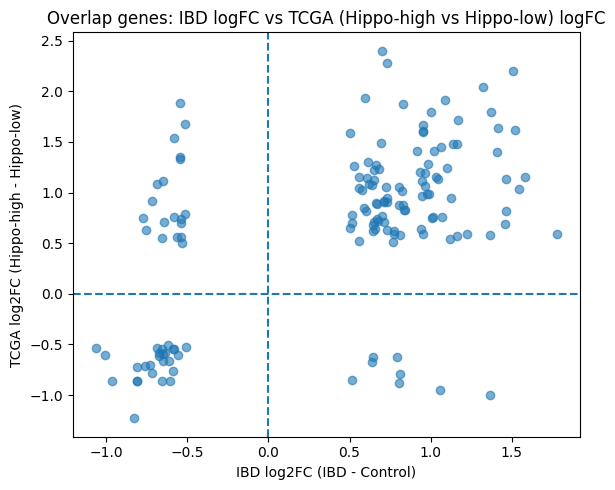

In [5]:
plt.figure(figsize=(6,5))
plt.scatter(m[IBD_LOGFC], m[TCGA_LOGFC], alpha=0.6)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.title("Overlap genes: IBD logFC vs TCGA (Hippo-high vs Hippo-low) logFC")
plt.xlabel("IBD log2FC (IBD - Control)")
plt.ylabel("TCGA log2FC (Hippo-high - Hippo-low)")
plt.tight_layout()
plt.savefig(f"{FIG}/overlap_scatter_IBD_vs_TCGA.png", dpi=200)
plt.show()


### Step-wise Summary of the Code

1. **Initialize figure**

   * Creates a matplotlib figure with size 6 × 5 inches.

2. **Generate scatter plot**

   * Plots IBD log2 fold change (`IBD_LOGFC`) on the x-axis.
   * Plots TCGA log2 fold change (`TCGA_LOGFC`) on the y-axis.
   * Sets point transparency (`alpha=0.6`).

3. **Add reference lines**

   * Adds horizontal dashed line at y = 0.
   * Adds vertical dashed line at x = 0.
   * These lines divide the plot into quadrants (up/down regulation).

4. **Add labels and title**

   * Sets descriptive plot title.
   * Labels x-axis (IBD log2FC: IBD − Control).
   * Labels y-axis (TCGA log2FC: Hippo-high − Hippo-low).

5. **Adjust layout**

   * Uses `tight_layout()` to optimize spacing.

6. **Save figure**

   * Saves the plot as a PNG file (`dpi=200`) in the specified figure directory `FIG`.

7. **Display plot**

   * Renders the plot on screen.

---

### One-line Summary

The code creates and saves a scatter plot comparing IBD and TCGA log2 fold changes for overlapping genes with quadrant reference lines.


**Build a “core signature” list**

Core = overlap genes with same direction + strongest evidence.

In [6]:
same = m[m["direction_match"]=="same_direction"].copy()

# rank by combined significance (simple scoring)
same["score"] = -np.log10(same["padj_fdr_IBD"] + 1e-300) + -np.log10(same["padj_fdr_TCGA"] + 1e-300)
same = same.sort_values("score", ascending=False)

core_genes = same["gene"].tolist()
pd.DataFrame({"core_signature_genes": core_genes}).to_csv(f"{OUT}/core_signature_genes.csv", index=False)

print("Core signature size:", len(core_genes))
display(same.head(15))


Core signature size: 120


,gene,logFC_IBD_minus_Control,padj_fdr_IBD,logFC_Hippo_high_minus_Hippo_low,padj_fdr_TCGA,direction_IBD,direction_TCGA,direction_match,score
94,TWIST1,0.702728,0.025665,2.401427,7.464519e-43,1.0,1.0,same_direction,43.717658
22,VASN,0.953542,0.002057,1.599485,1.547573e-38,1.0,1.0,same_direction,40.497139
33,SPON2,0.950484,0.004498,1.613181,7.974190e-33,1.0,1.0,same_direction,34.445255
36,A4GALT,0.953062,0.005349,1.663773,1.043555e-31,1.0,1.0,same_direction,33.253177
139,SNAI1,0.611568,0.044977,1.301726,2.457506e-31,1.0,1.0,same_direction,31.956511
44,PDLIM7,1.042980,0.006272,1.137792,2.634049e-27,1.0,1.0,same_direction,28.781946
4,UBTD1,0.967413,0.000120,1.066508,6.093768e-25,1.0,1.0,same_direction,28.135413
42,SPHK1,1.003009,0.005606,1.796597,1.428962e-26,1.0,1.0,same_direction,28.096358
15,PRRX2,0.594524,0.000709,1.933811,1.304898e-24,1.0,1.0,same_direction,27.033915
46,LILRA2,0.830649,0.006337,1.872712,2.406948e-25,1.0,1.0,same_direction,26.816623


### Step-wise Summary of the Code

1. **Select concordant genes**

   * Filters merged dataset `m` to retain only genes labeled `"same_direction"`.
   * Creates a copy named `same`.

2. **Compute combined significance score**

   * Calculates a score for each gene:
     [
     -\log_{10}(padj_fdr_IBD) + -\log_{10}(padj_fdr_TCGA)
     ]
   * Adds a small constant (`1e-300`) to avoid log(0).
   * Stores result in a new column `"score"`.

3. **Rank genes by score**

   * Sorts genes in descending order of combined significance.

4. **Extract core signature genes**

   * Converts the ranked gene list into `core_genes`.

5. **Export core signature**

   * Saves the gene list as `core_signature_genes.csv` in the output directory `OUT`.

6. **Summarize results**

   * Prints total number of core signature genes.
   * Displays the top 15 highest-scoring genes.

---

### One-line Summary

The code identifies concordantly regulated genes, ranks them by combined statistical significance, and exports the ranked core signature gene list.


Heatmap

Genes used for heatmap-like plot: 20


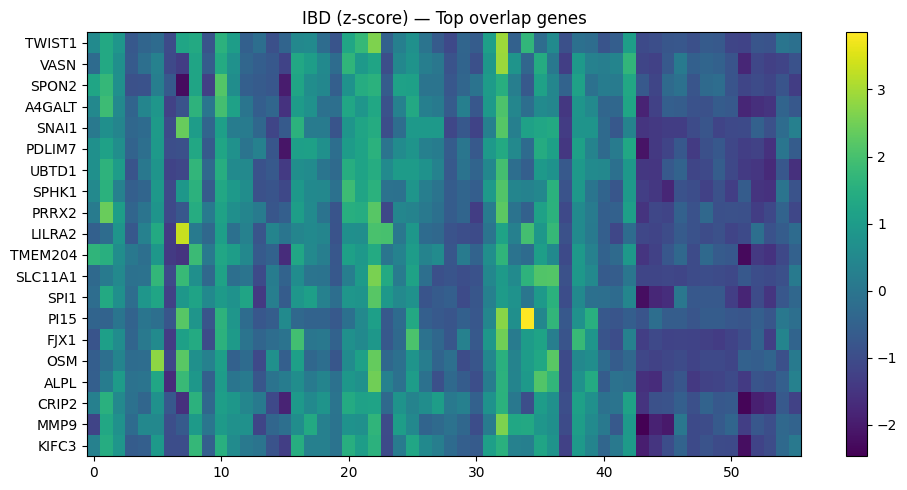

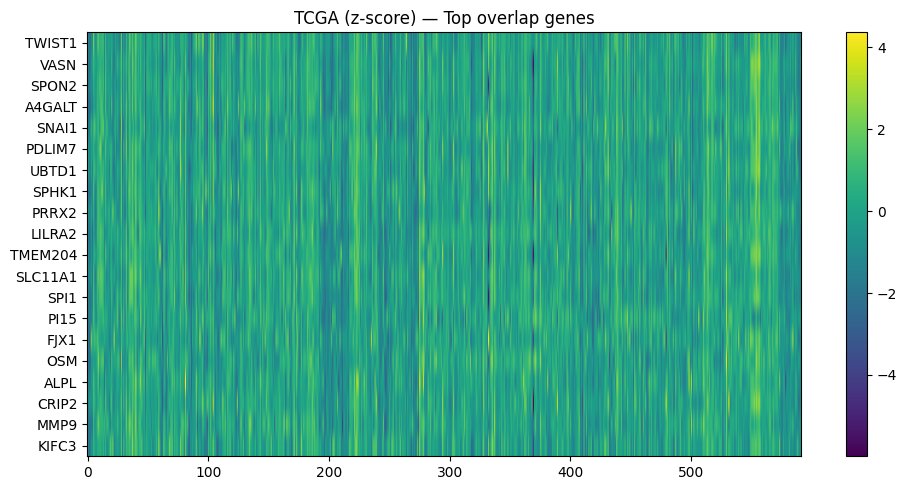

In [7]:
topN = 20
top_genes = core_genes[:topN]

if len(top_genes) < 3:
    print("Core list too small. Lower abs_logfc threshold (e.g., 0.5) in filtering step.")
else:
    ibd_log  = pd.read_csv(IBD_LOG, index_col=0)
    tcga_log = pd.read_csv(TCGA_LOG, index_col=0)

    # keep only genes present
    top_genes = [g for g in top_genes if (g in ibd_log.index and g in tcga_log.index)]
    print("Genes used for heatmap-like plot:", len(top_genes))

    def z(expr):
        return expr.sub(expr.mean(1), axis=0).div(expr.std(1).replace(0, np.nan), axis=0).fillna(0)

    ibd_v  = z(ibd_log.loc[top_genes])
    tcga_v = z(tcga_log.loc[top_genes])

    plt.figure(figsize=(10,5))
    plt.imshow(ibd_v.values, aspect="auto")
    plt.yticks(range(len(top_genes)), top_genes)
    plt.title("IBD (z-score) — Top overlap genes")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(f"{FIG}/IBD_top_overlap_heatmaplike.png", dpi=200)
    plt.show()

    plt.figure(figsize=(10,5))
    plt.imshow(tcga_v.values, aspect="auto")
    plt.yticks(range(len(top_genes)), top_genes)
    plt.title("TCGA (z-score) — Top overlap genes")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(f"{FIG}/TCGA_top_overlap_heatmaplike.png", dpi=200)
    plt.show()


### Step-wise Summary of the Code

1. **Select top N core genes**

   * Sets `topN = 20`.
   * Extracts the first 20 genes from `core_genes` into `top_genes`.

2. **Check minimum gene requirement**

   * If fewer than 3 genes are available, prints a warning suggesting lowering the `abs_logfc` threshold.
   * Otherwise proceeds with visualization.

3. **Load log-expression matrices**

   * Reads IBD log-expression matrix (`IBD_LOG`) with genes as index.
   * Reads TCGA log-expression matrix (`TCGA_LOG`) with genes as index.

4. **Filter genes present in both datasets**

   * Retains only genes found in both expression matrices.
   * Prints the number of genes used for plotting.

5. **Define z-score normalization function**

   * For each gene (row):

     * Subtracts row mean.
     * Divides by row standard deviation.
     * Replaces zero SD with NaN to avoid division errors.
     * Fills NaN values with 0.

6. **Compute normalized expression values**

   * Applies z-score normalization to selected genes for IBD (`ibd_v`).
   * Applies z-score normalization to selected genes for TCGA (`tcga_v`).

7. **Generate IBD heatmap-like plot**

   * Creates figure (10 × 5 inches).
   * Displays normalized expression using `imshow`.
   * Labels y-axis with gene names.
   * Adds title and colorbar.
   * Saves as `IBD_top_overlap_heatmaplike.png`.
   * Displays the plot.

8. **Generate TCGA heatmap-like plot**

   * Repeats same process for TCGA data.
   * Saves as `TCGA_top_overlap_heatmaplike.png`.
   * Displays the plot.

---

### One-line Summary

The code selects top overlap genes, performs row-wise z-score normalization of expression data, and generates heatmap-like visualizations for IBD and TCGA datasets.


**Enrichment** **analysis**

In [8]:
try:
    import gseapy as gp
except ImportError:
    !pip -q install gseapy
    import gseapy as gp

if len(core_genes) >= 5:
    enr = gp.enrichr(
        gene_list=core_genes,
        gene_sets=["GO_Biological_Process_2021", "KEGG_2021_Human", "MSigDB_Hallmark_2020"],
        organism="Human",
        outdir=None
    )
    res = enr.results.sort_values("Adjusted P-value")
    res.to_csv(f"{OUT}/core_signature_enrichment.csv", index=False)
    print("Saved ->", f"{OUT}/core_signature_enrichment.csv")
    display(res.head(20))
else:
    print("Not enough core genes for enrichment. Lower thresholds in filter step.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 11.7 MB/s eta 0:00:00
Saved -> /content/drive/MyDrive/Colon_cancer_project/results/novelty/core_signature_enrichment.csv


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,TNF-alpha Signaling via NF-kB,7/200,0.000206,0.006193,0,0,6.318905,53.618858,CEBPB;SPHK1;PMEPA1;G0S2;SLC2A6;JUNB;FJX1
30,GO_Biological_Process_2021,TNF-alpha Signaling via NF-kB,7/200,0.000206,0.006193,0,0,6.318905,53.618858,CEBPB;SPHK1;PMEPA1;G0S2;SLC2A6;JUNB;FJX1
60,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,7/200,0.000206,0.006193,0,0,6.318905,53.618858,CEBPB;SPHK1;PMEPA1;G0S2;SLC2A6;JUNB;FJX1
2,KEGG_2021_Human,Inflammatory Response,6/200,0.001318,0.013181,0,0,5.340749,35.417696,CSF3;CD70;SPHK1;OSM;PROK2;LY6E
31,GO_Biological_Process_2021,Myogenesis,6/200,0.001318,0.013181,0,0,5.340749,35.417696,PTP4A3;MB;SPHK1;KIFC3;MAPK12;PDLIM7
61,MSigDB_Hallmark_2020,Myogenesis,6/200,0.001318,0.013181,0,0,5.340749,35.417696,PTP4A3;MB;SPHK1;KIFC3;MAPK12;PDLIM7
32,GO_Biological_Process_2021,Inflammatory Response,6/200,0.001318,0.013181,0,0,5.340749,35.417696,CSF3;CD70;SPHK1;OSM;PROK2;LY6E
1,KEGG_2021_Human,Myogenesis,6/200,0.001318,0.013181,0,0,5.340749,35.417696,PTP4A3;MB;SPHK1;KIFC3;MAPK12;PDLIM7
62,MSigDB_Hallmark_2020,Inflammatory Response,6/200,0.001318,0.013181,0,0,5.340749,35.417696,CSF3;CD70;SPHK1;OSM;PROK2;LY6E
34,GO_Biological_Process_2021,Allograft Rejection,4/200,0.032520,0.174771,0,0,3.463054,11.864064,IL11;SPI1;CDKN2A;MMP9


### Step-wise Summary of the Code

1. **Ensure `gseapy` is available**

   * Attempts to import the `gseapy` library.
   * If not installed, installs it using `pip` and then imports it.

2. **Check minimum gene requirement for enrichment**

   * Proceeds only if `core_genes` contains at least 5 genes.
   * Otherwise prints a message suggesting lowering filtering thresholds.

3. **Perform functional enrichment analysis**

   * Uses `gp.enrichr()` with:

     * `gene_list = core_genes`
     * Gene set libraries:

       * `"GO_Biological_Process_2021"`
       * `"KEGG_2021_Human"`
       * `"MSigDB_Hallmark_2020"`
     * `organism = "Human"`
     * No output directory (`outdir=None`).

4. **Process enrichment results**

   * Sorts results by `"Adjusted P-value"` (ascending significance).
   * Saves the full enrichment table as `core_signature_enrichment.csv` in `OUT`.

5. **Display top enriched terms**

   * Prints file save confirmation.
   * Displays the top 20 enriched pathways/terms.

---

### One-line Summary

The code performs Enrichr-based functional enrichment analysis on core signature genes and saves ranked enrichment results if sufficient genes are available.


# Task
```python
import matplotlib.pyplot as plt

# Check if enrichment results exist and are not empty
if 'res' in locals() and not res.empty:
    # Get unique gene sets from the results DataFrame
    gene_sets = res['Gene_set'].unique()

    for gs_name in gene_sets:
        # Filter results for the current gene set
        res_gs = res[res['Gene_set'] == gs_name].copy()

        if res_gs.empty:
            print(f"No significant results found for gene set: '{gs_name}'. Skipping plots.")
            continue

        # Create a safe filename by replacing spaces and slashes with underscores
        safe_gs_name = gs_name.replace(' ', '_').replace('/', '_')

        # Define output paths for dotplot and barplot
        dotplot_path = f"{FIG}/{safe_gs_name}_dotplot.png"
        barplot_path = f"{FIG}/{safe_gs_name}_barplot.png"

        # Generate and save Dotplot
        print(f"Generating dotplot for '{gs_name}' to '{dotplot_path}'")
        try:
            gp.dotplot(
                res_gs,
                title=f"Enrichment Dotplot: {gs_name}",
                cmap='viridis_r',  # Invert colormap so smaller p-values are darker/more intense
                ofname=dotplot_path,
                figsize=(8, 6),
                top_term=20,  # Display top 20 terms for readability
                cutoff=0.05   # Only display terms with Adjusted P-value < 0.05
            )
            plt.close()  # Close the plot to prevent displaying it and free memory
        except Exception as e:
            print(f"Error generating dotplot for '{gs_name}': {e}")

        # Generate and save Barplot
        print(f"Generating barplot for '{gs_name}' to '{barplot_path}'")
        try:
            gp.barplot(
                res_gs,
                title=f"Enrichment Barplot: {gs_name}",
                column='Adjusted P-value',  # Bar height represents -log10(Adjusted P-value)
                ofname=barplot_path,
                figsize=(8, 6),
                top_term=20,  # Display top 20 terms for readability
                cutoff=0.05,  # Only display terms with Adjusted P-value < 0.05
                color='salmon' # Define a consistent color for the bars
            )
            plt.close()  # Close the plot to prevent displaying it and free memory
        except Exception as e:
            print(f"Error generating barplot for '{gs_name}': {e}")

else:
    print("Enrichment results (res DataFrame) not found or are empty. Skipping plot generation.")
```

In [9]:
import matplotlib.pyplot as plt

# Check if enrichment results exist and are not empty
if 'res' in locals() and not res.empty:
    # Get unique gene sets from the results DataFrame
    gene_sets = res['Gene_set'].unique()

    for gs_name in gene_sets:
        # Filter results for the current gene set
        res_gs = res[res['Gene_set'] == gs_name].copy()

        if res_gs.empty:
            print(f"No significant results found for gene set: '{gs_name}'. Skipping plots.")
            continue

        # Create a safe filename by replacing spaces and slashes with underscores
        safe_gs_name = gs_name.replace(' ', '_').replace('/', '_')

        # Define output paths for dotplot and barplot
        dotplot_path = f"{FIG}/{safe_gs_name}_dotplot.png"
        barplot_path = f"{FIG}/{safe_gs_name}_barplot.png"

        # Generate and save Dotplot
        print(f"Generating dotplot for '{gs_name}' to '{dotplot_path}'")
        try:
            gp.dotplot(
                res_gs,
                title=f"Enrichment Dotplot: {gs_name}",
                cmap='viridis_r',  # Invert colormap so smaller p-values are darker/more intense
                ofname=dotplot_path,
                figsize=(8, 6),
                top_term=20,  # Display top 20 terms for readability
                cutoff=0.05   # Only display terms with Adjusted P-value < 0.05
            )
            plt.close()  # Close the plot to prevent displaying it and free memory
        except Exception as e:
            print(f"Error generating dotplot for '{gs_name}': {e}")

        # Generate and save Barplot
        print(f"Generating barplot for '{gs_name}' to '{barplot_path}'")
        try:
            gp.barplot(
                res_gs,
                title=f"Enrichment Barplot: {gs_name}",
                column='Adjusted P-value',  # Bar height represents -log10(Adjusted P-value)
                ofname=barplot_path,
                figsize=(8, 6),
                top_term=20,  # Display top 20 terms for readability
                cutoff=0.05,  # Only display terms with Adjusted P-value < 0.05
                color='salmon' # Define a consistent color for the bars
            )
            plt.close()  # Close the plot to prevent displaying it and free memory
        except Exception as e:
            print(f"Error generating barplot for '{gs_name}': {e}")

else:
    print("Enrichment results (res DataFrame) not found or are empty. Skipping plot generation.")

Generating dotplot for 'KEGG_2021_Human' to '/content/drive/MyDrive/Colon_cancer_project/results/figures/novelty/KEGG_2021_Human_dotplot.png'
Generating barplot for 'KEGG_2021_Human' to '/content/drive/MyDrive/Colon_cancer_project/results/figures/novelty/KEGG_2021_Human_barplot.png'
Generating dotplot for 'GO_Biological_Process_2021' to '/content/drive/MyDrive/Colon_cancer_project/results/figures/novelty/GO_Biological_Process_2021_dotplot.png'
Generating barplot for 'GO_Biological_Process_2021' to '/content/drive/MyDrive/Colon_cancer_project/results/figures/novelty/GO_Biological_Process_2021_barplot.png'
Generating dotplot for 'MSigDB_Hallmark_2020' to '/content/drive/MyDrive/Colon_cancer_project/results/figures/novelty/MSigDB_Hallmark_2020_dotplot.png'
Generating barplot for 'MSigDB_Hallmark_2020' to '/content/drive/MyDrive/Colon_cancer_project/results/figures/novelty/MSigDB_Hallmark_2020_barplot.png'


Import plotting library,Check availability of enrichment results, Identify gene set categories, Iterate over each gene set, Prepare safe output filenames

Replaces spaces and slashes in gene set names with underscores.

Defines file paths for dotplot and barplot images.

Generate and save dotplot

Uses gp.dotplot() with:

Top 20 enriched terms.

Adjusted P-value cutoff < 0.05.

Inverted viridis_r colormap (smaller p-values appear darker).

Saves plot to file and closes figure.

Catches and reports errors if plotting fails.

Generate and save barplot

Uses gp.barplot() with:

Bar height representing adjusted P-values.

Top 20 terms.

Adjusted P-value cutoff < 0.05.

Fixed bar color (salmon).

Saves plot to file and closes figure.

Catches and reports errors if plotting fails.

Fallback behavior

If enrichment results are unavailable, prints a message and skips plot generation.

One-line Summary

The code generates and saves dotplots and barplots for each enriched gene set from the enrichment results, handling errors and skipping empty results.

Displaying dotplot for KEGG_2021_Human:


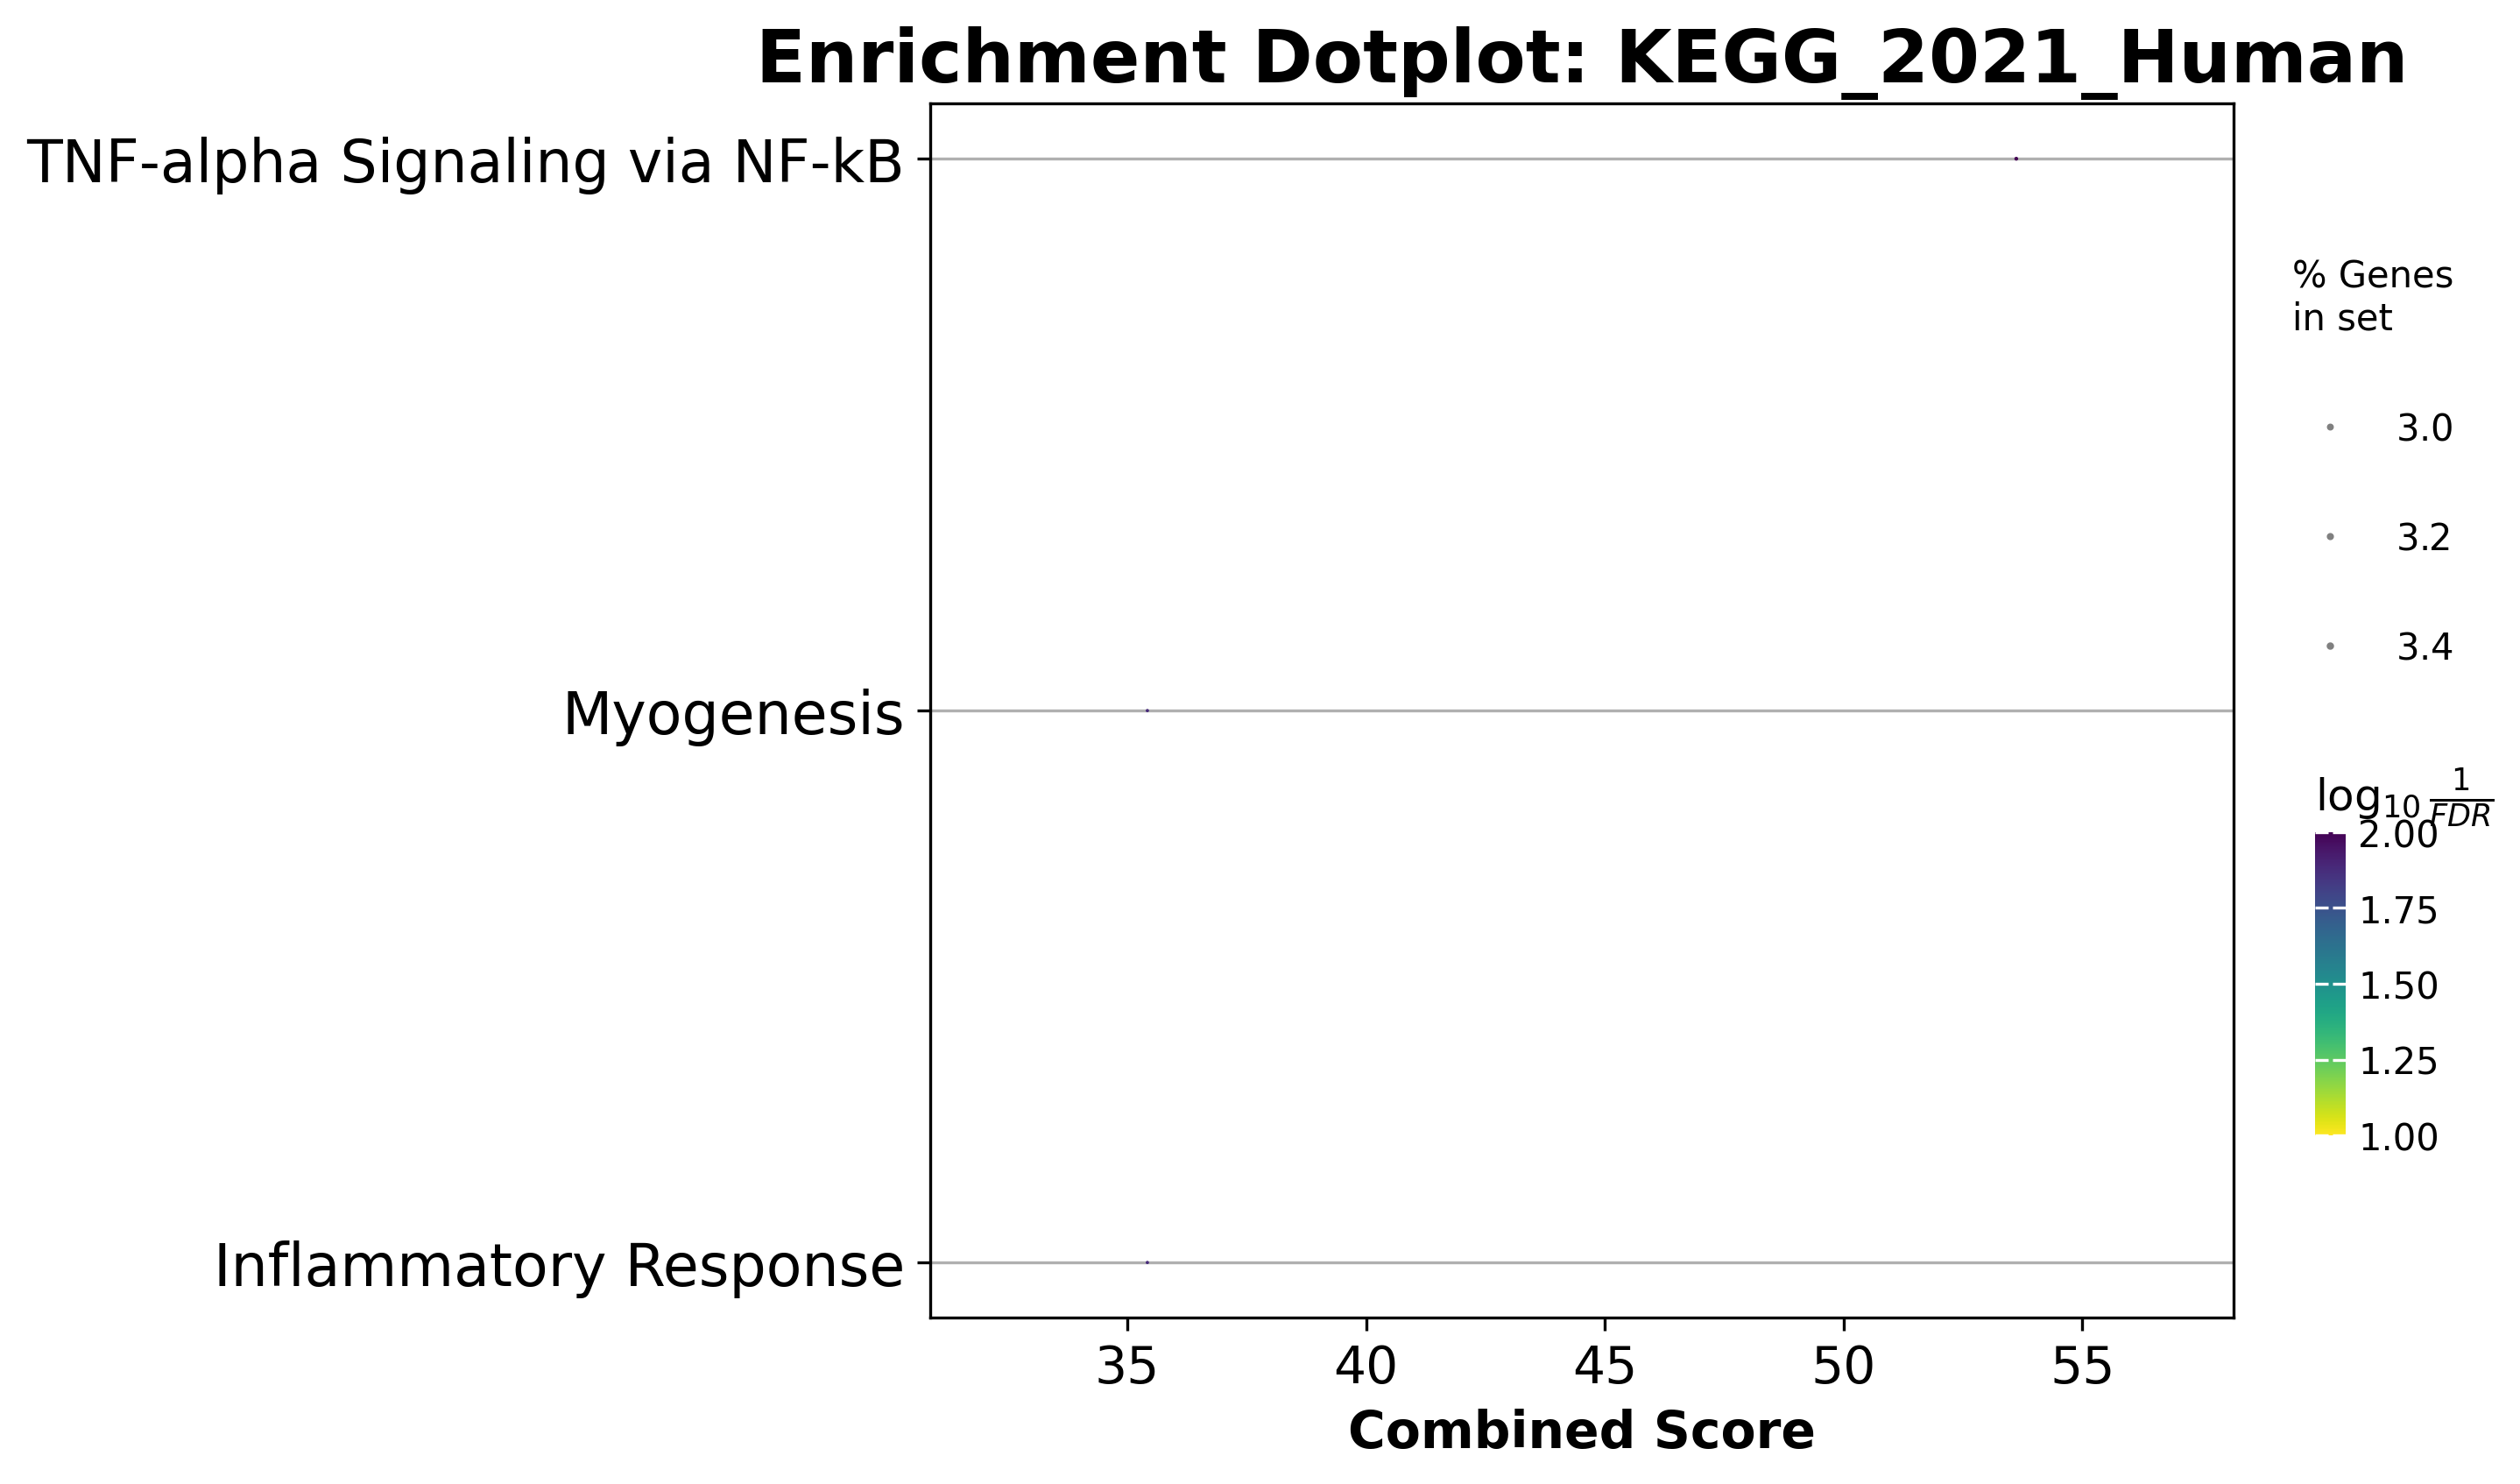

Displaying barplot for KEGG_2021_Human:


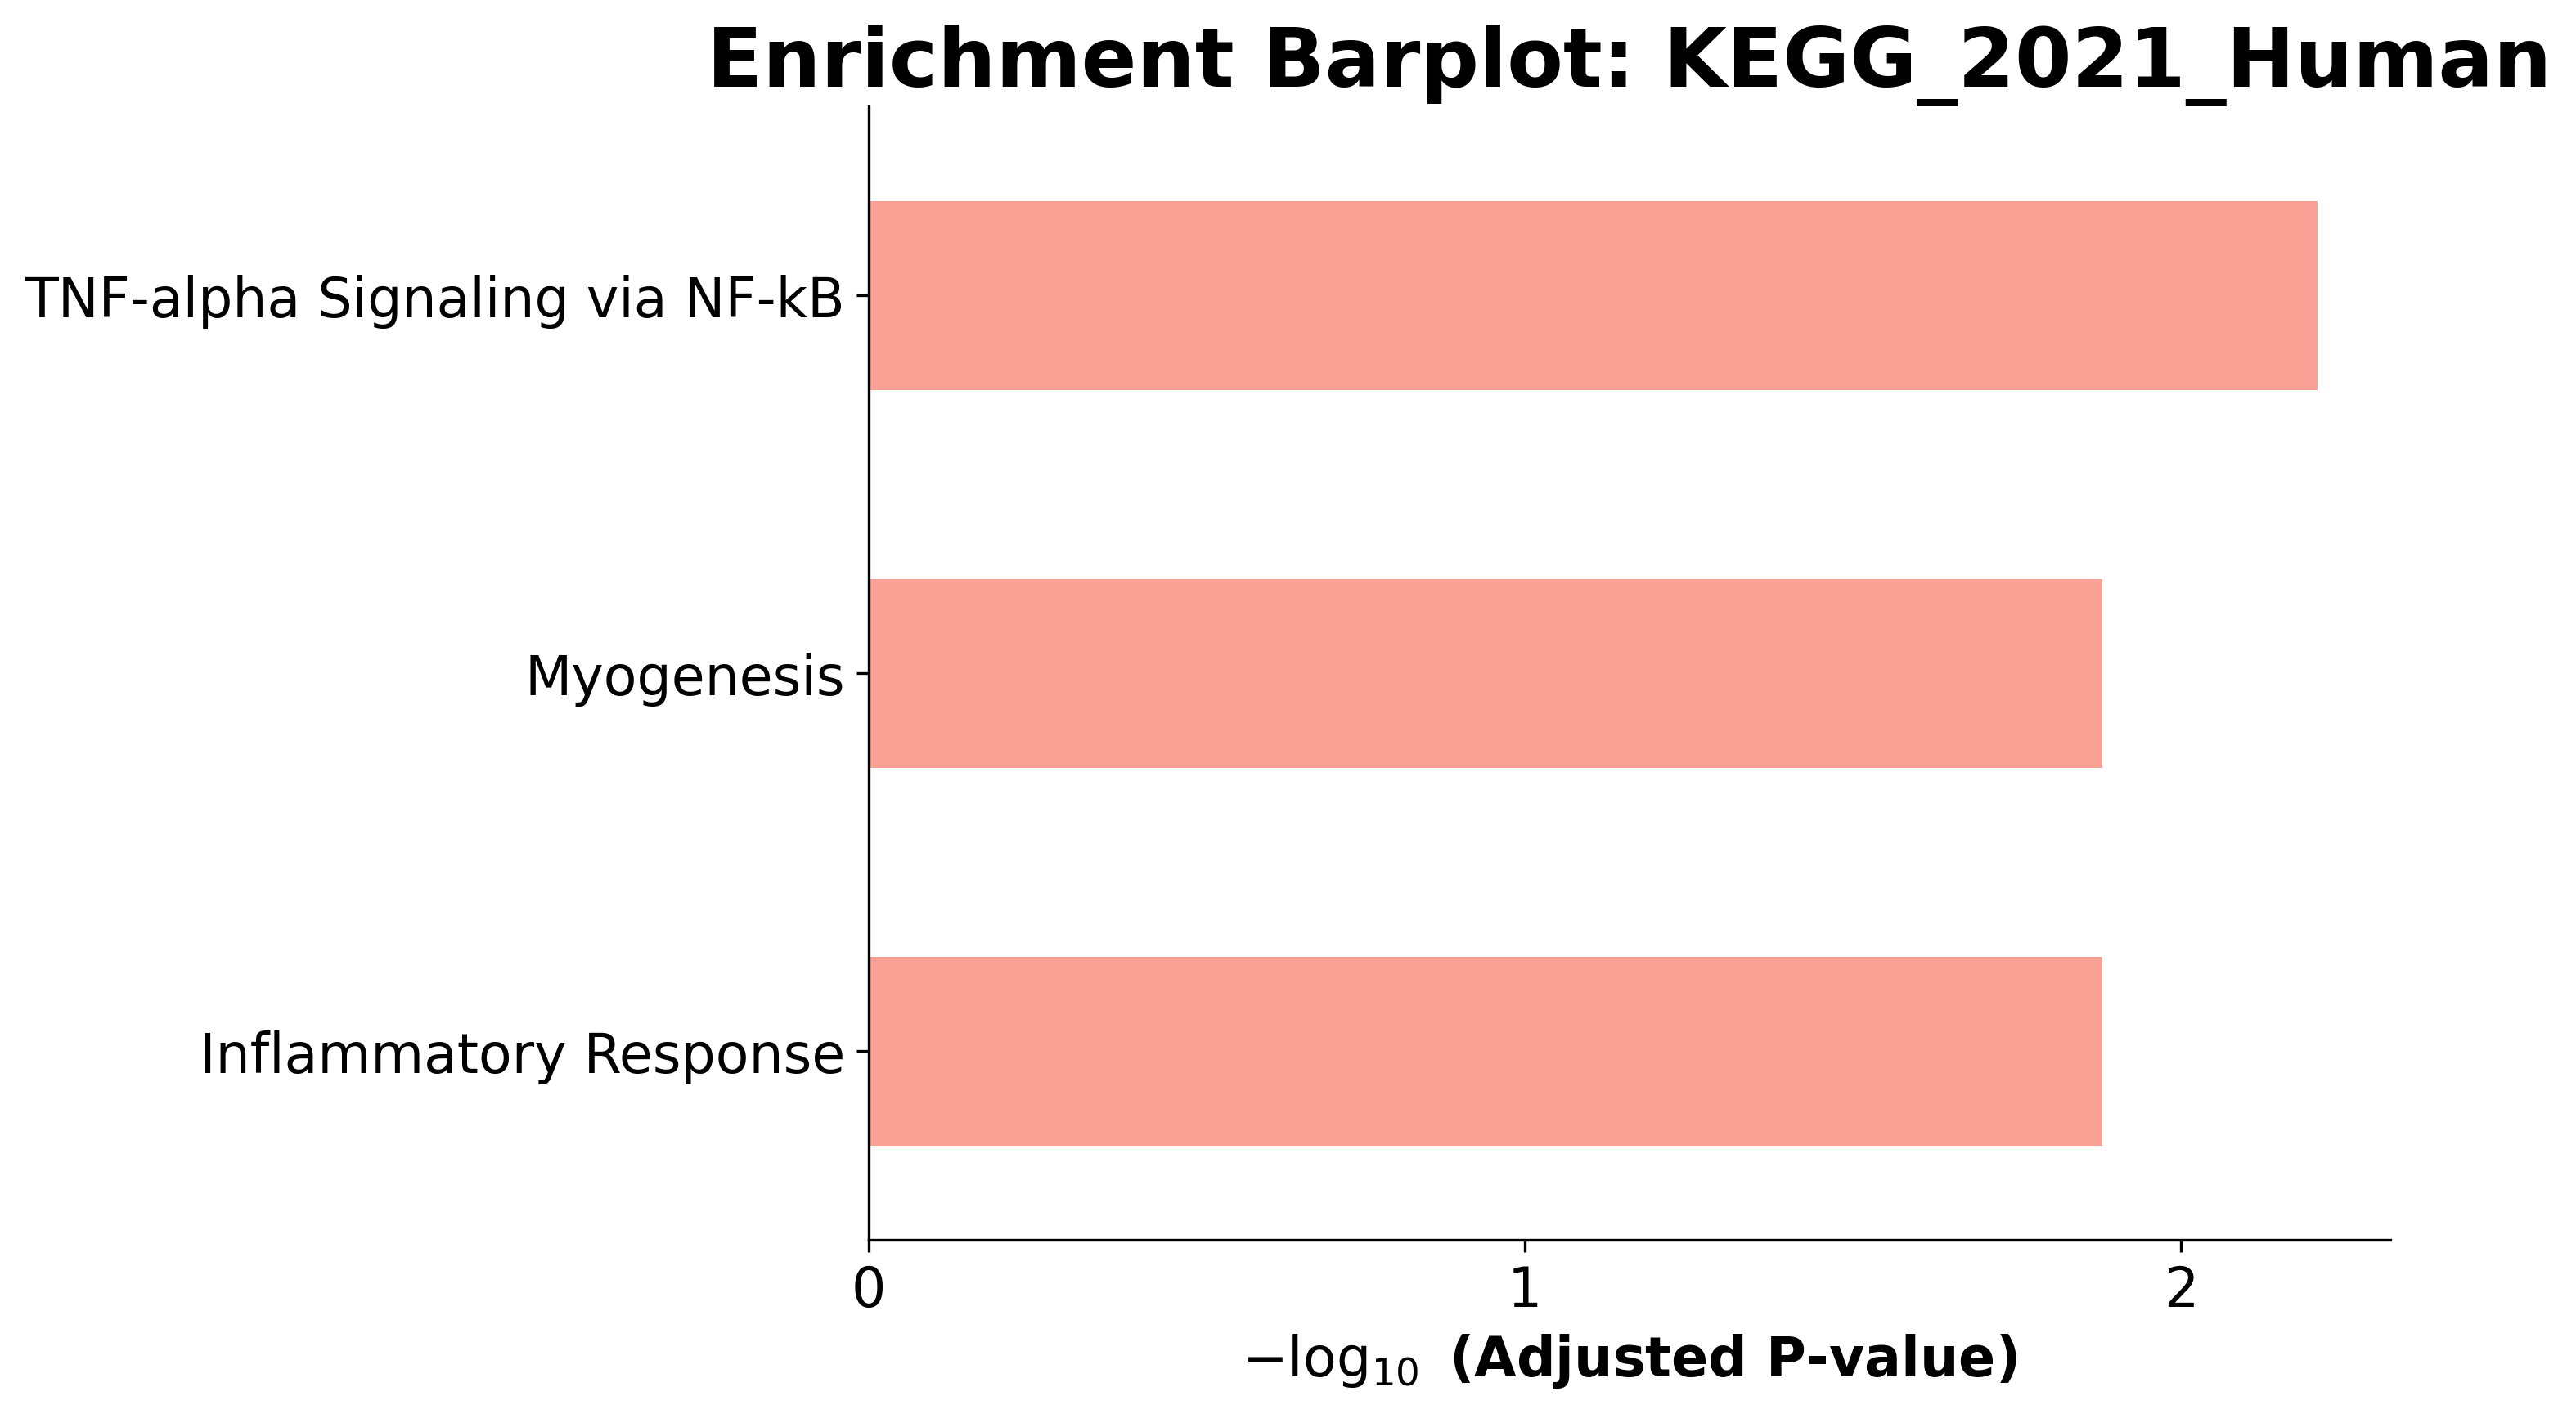

Displaying dotplot for GO_Biological_Process_2021:


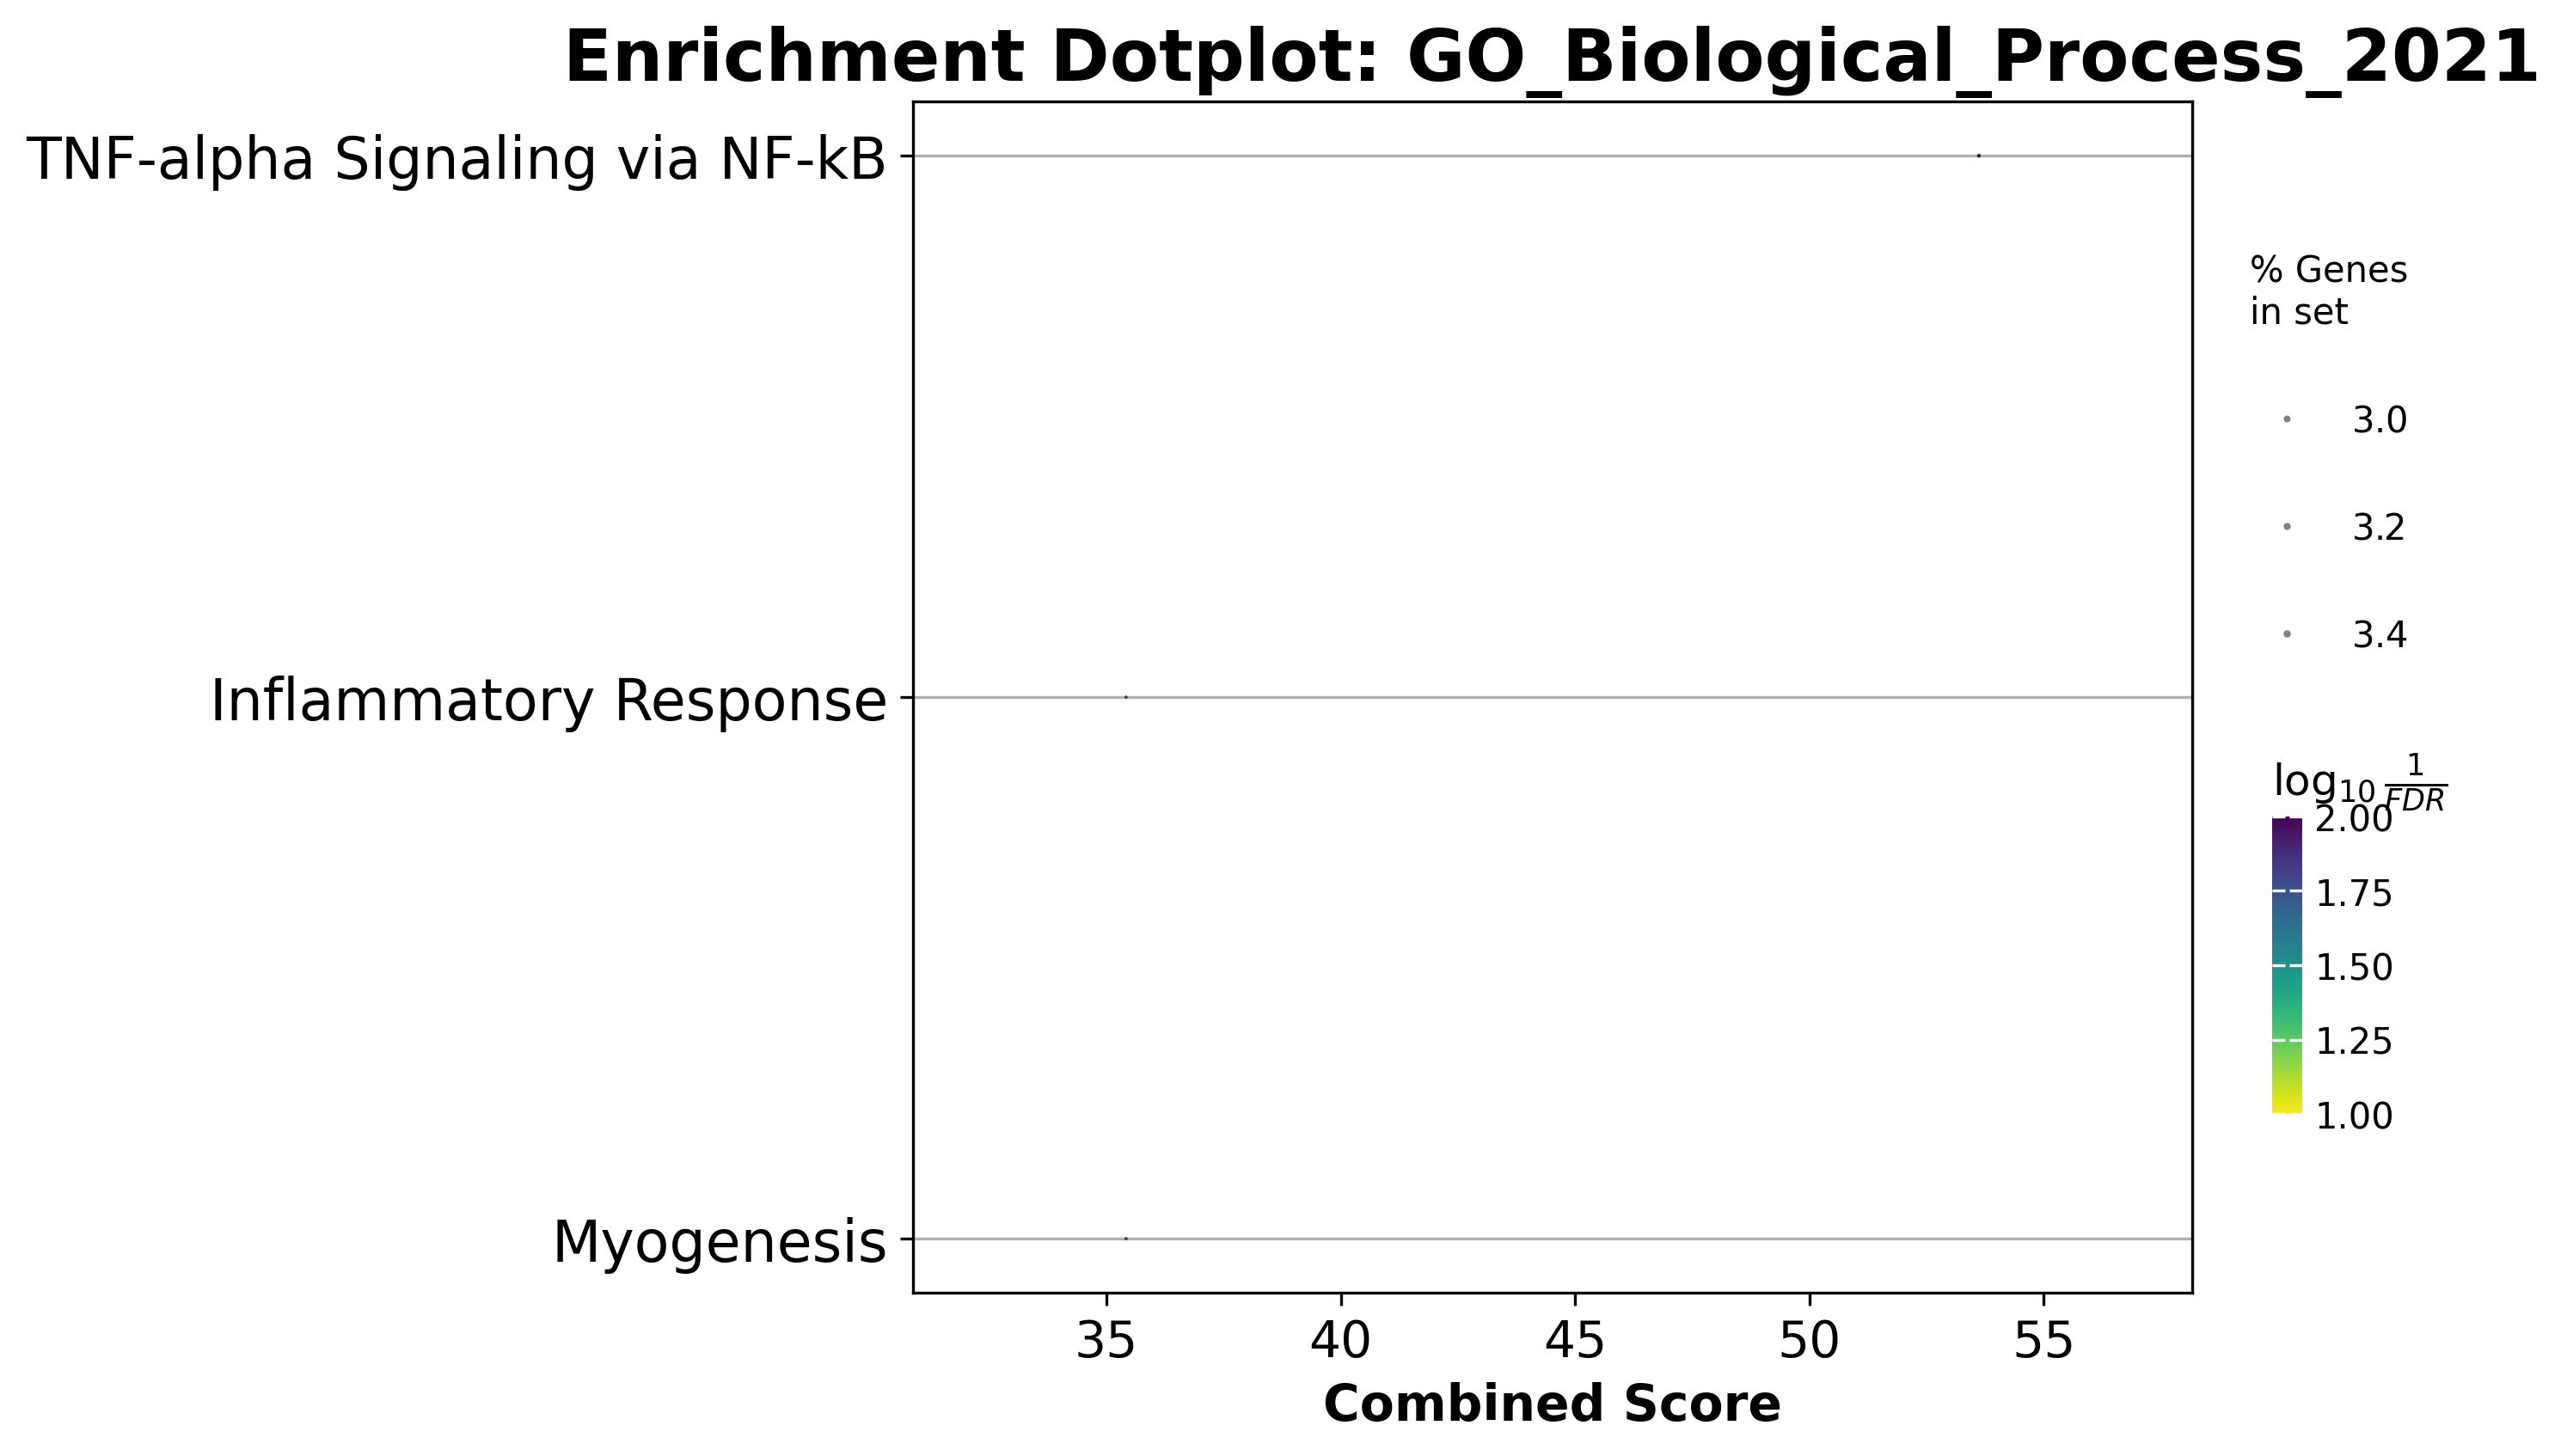

Displaying barplot for GO_Biological_Process_2021:


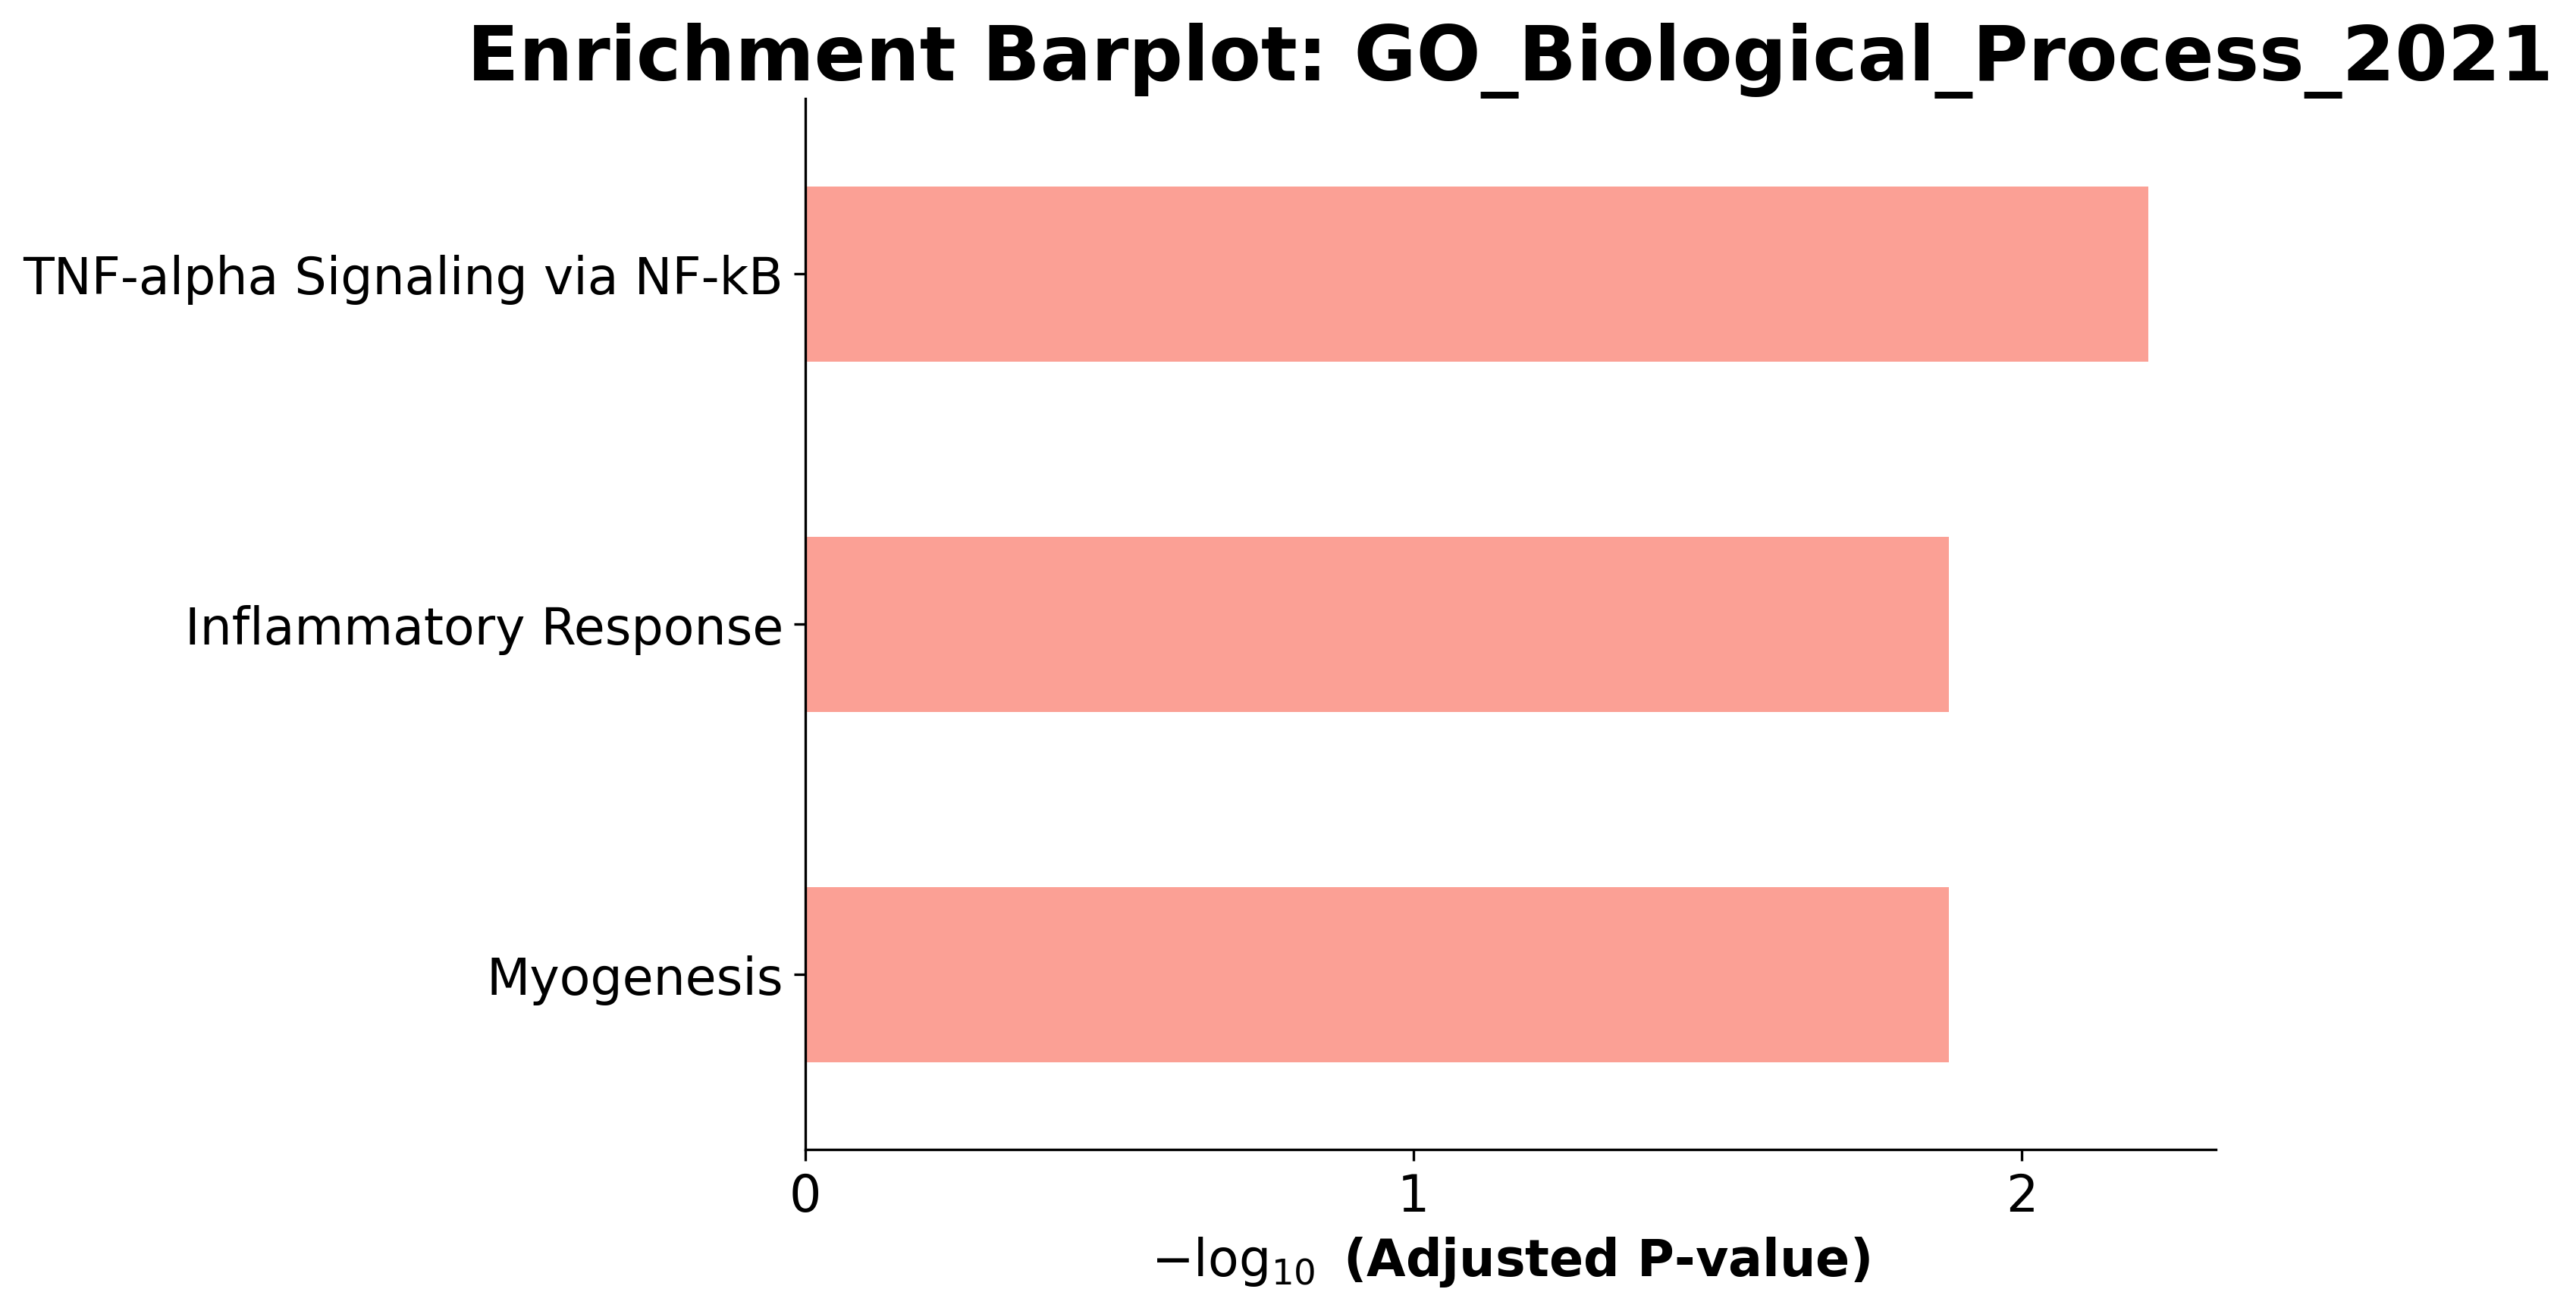

Displaying dotplot for MSigDB_Hallmark_2020:


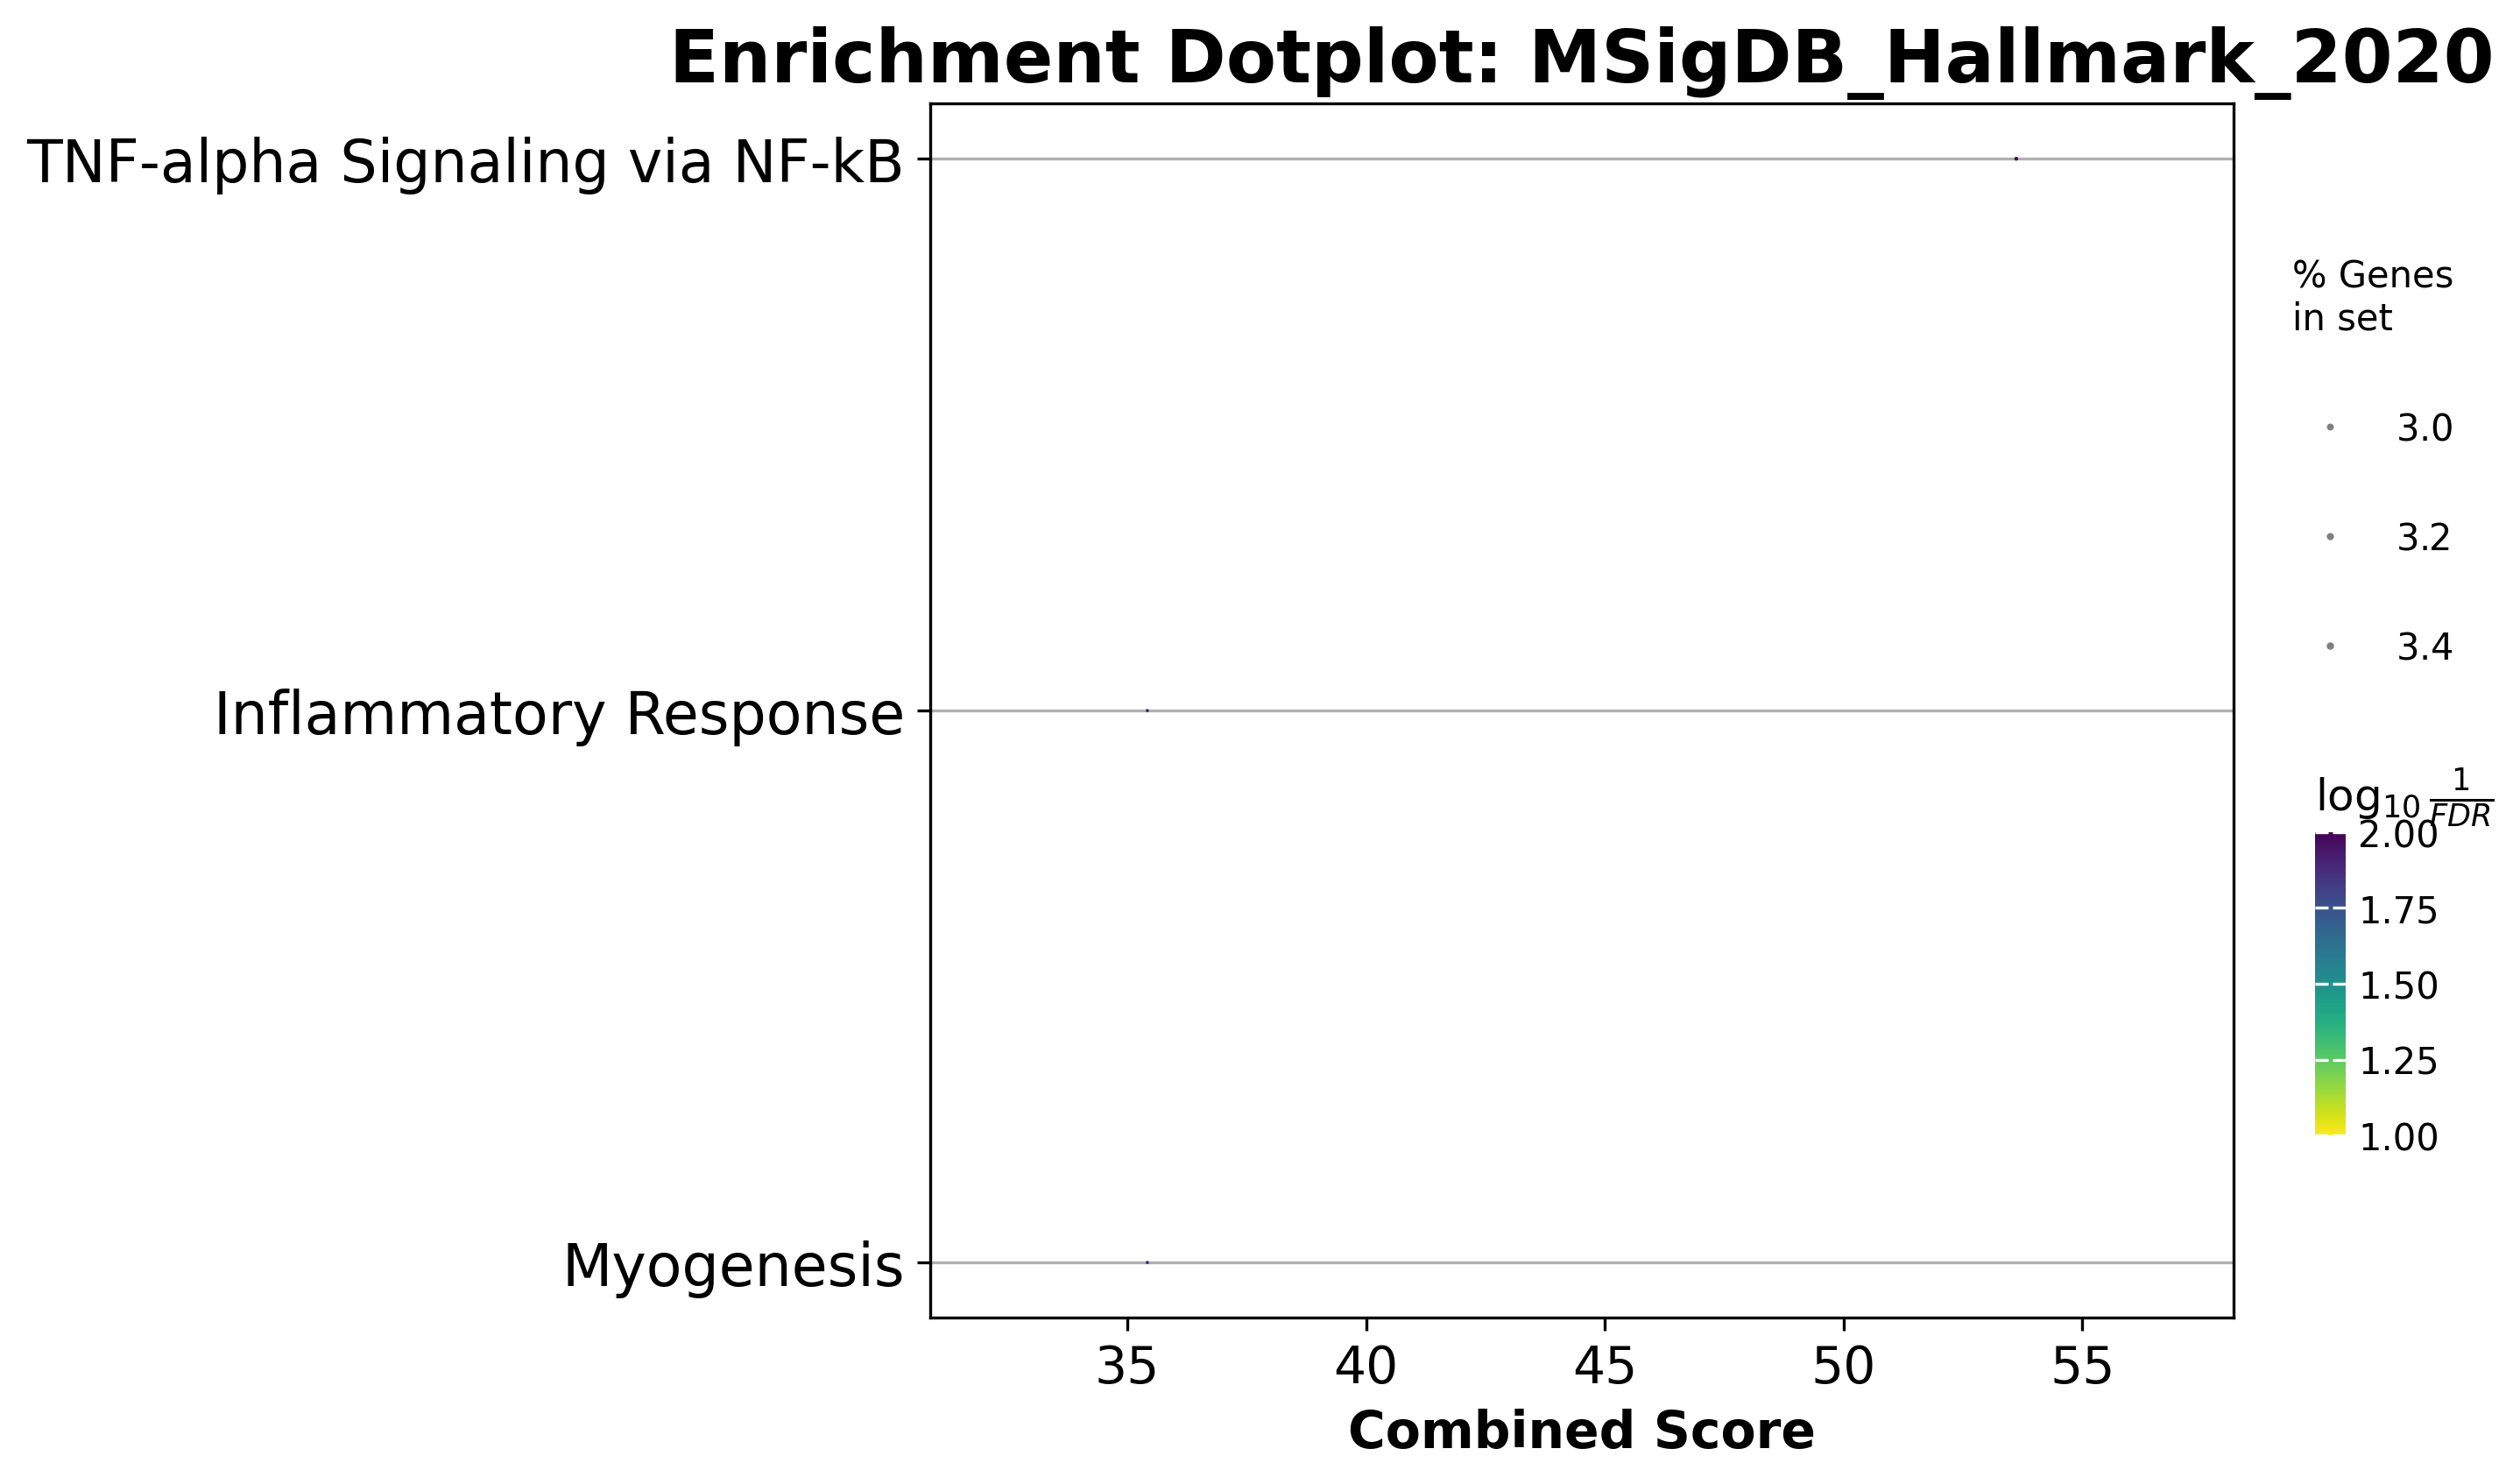

Displaying barplot for MSigDB_Hallmark_2020:


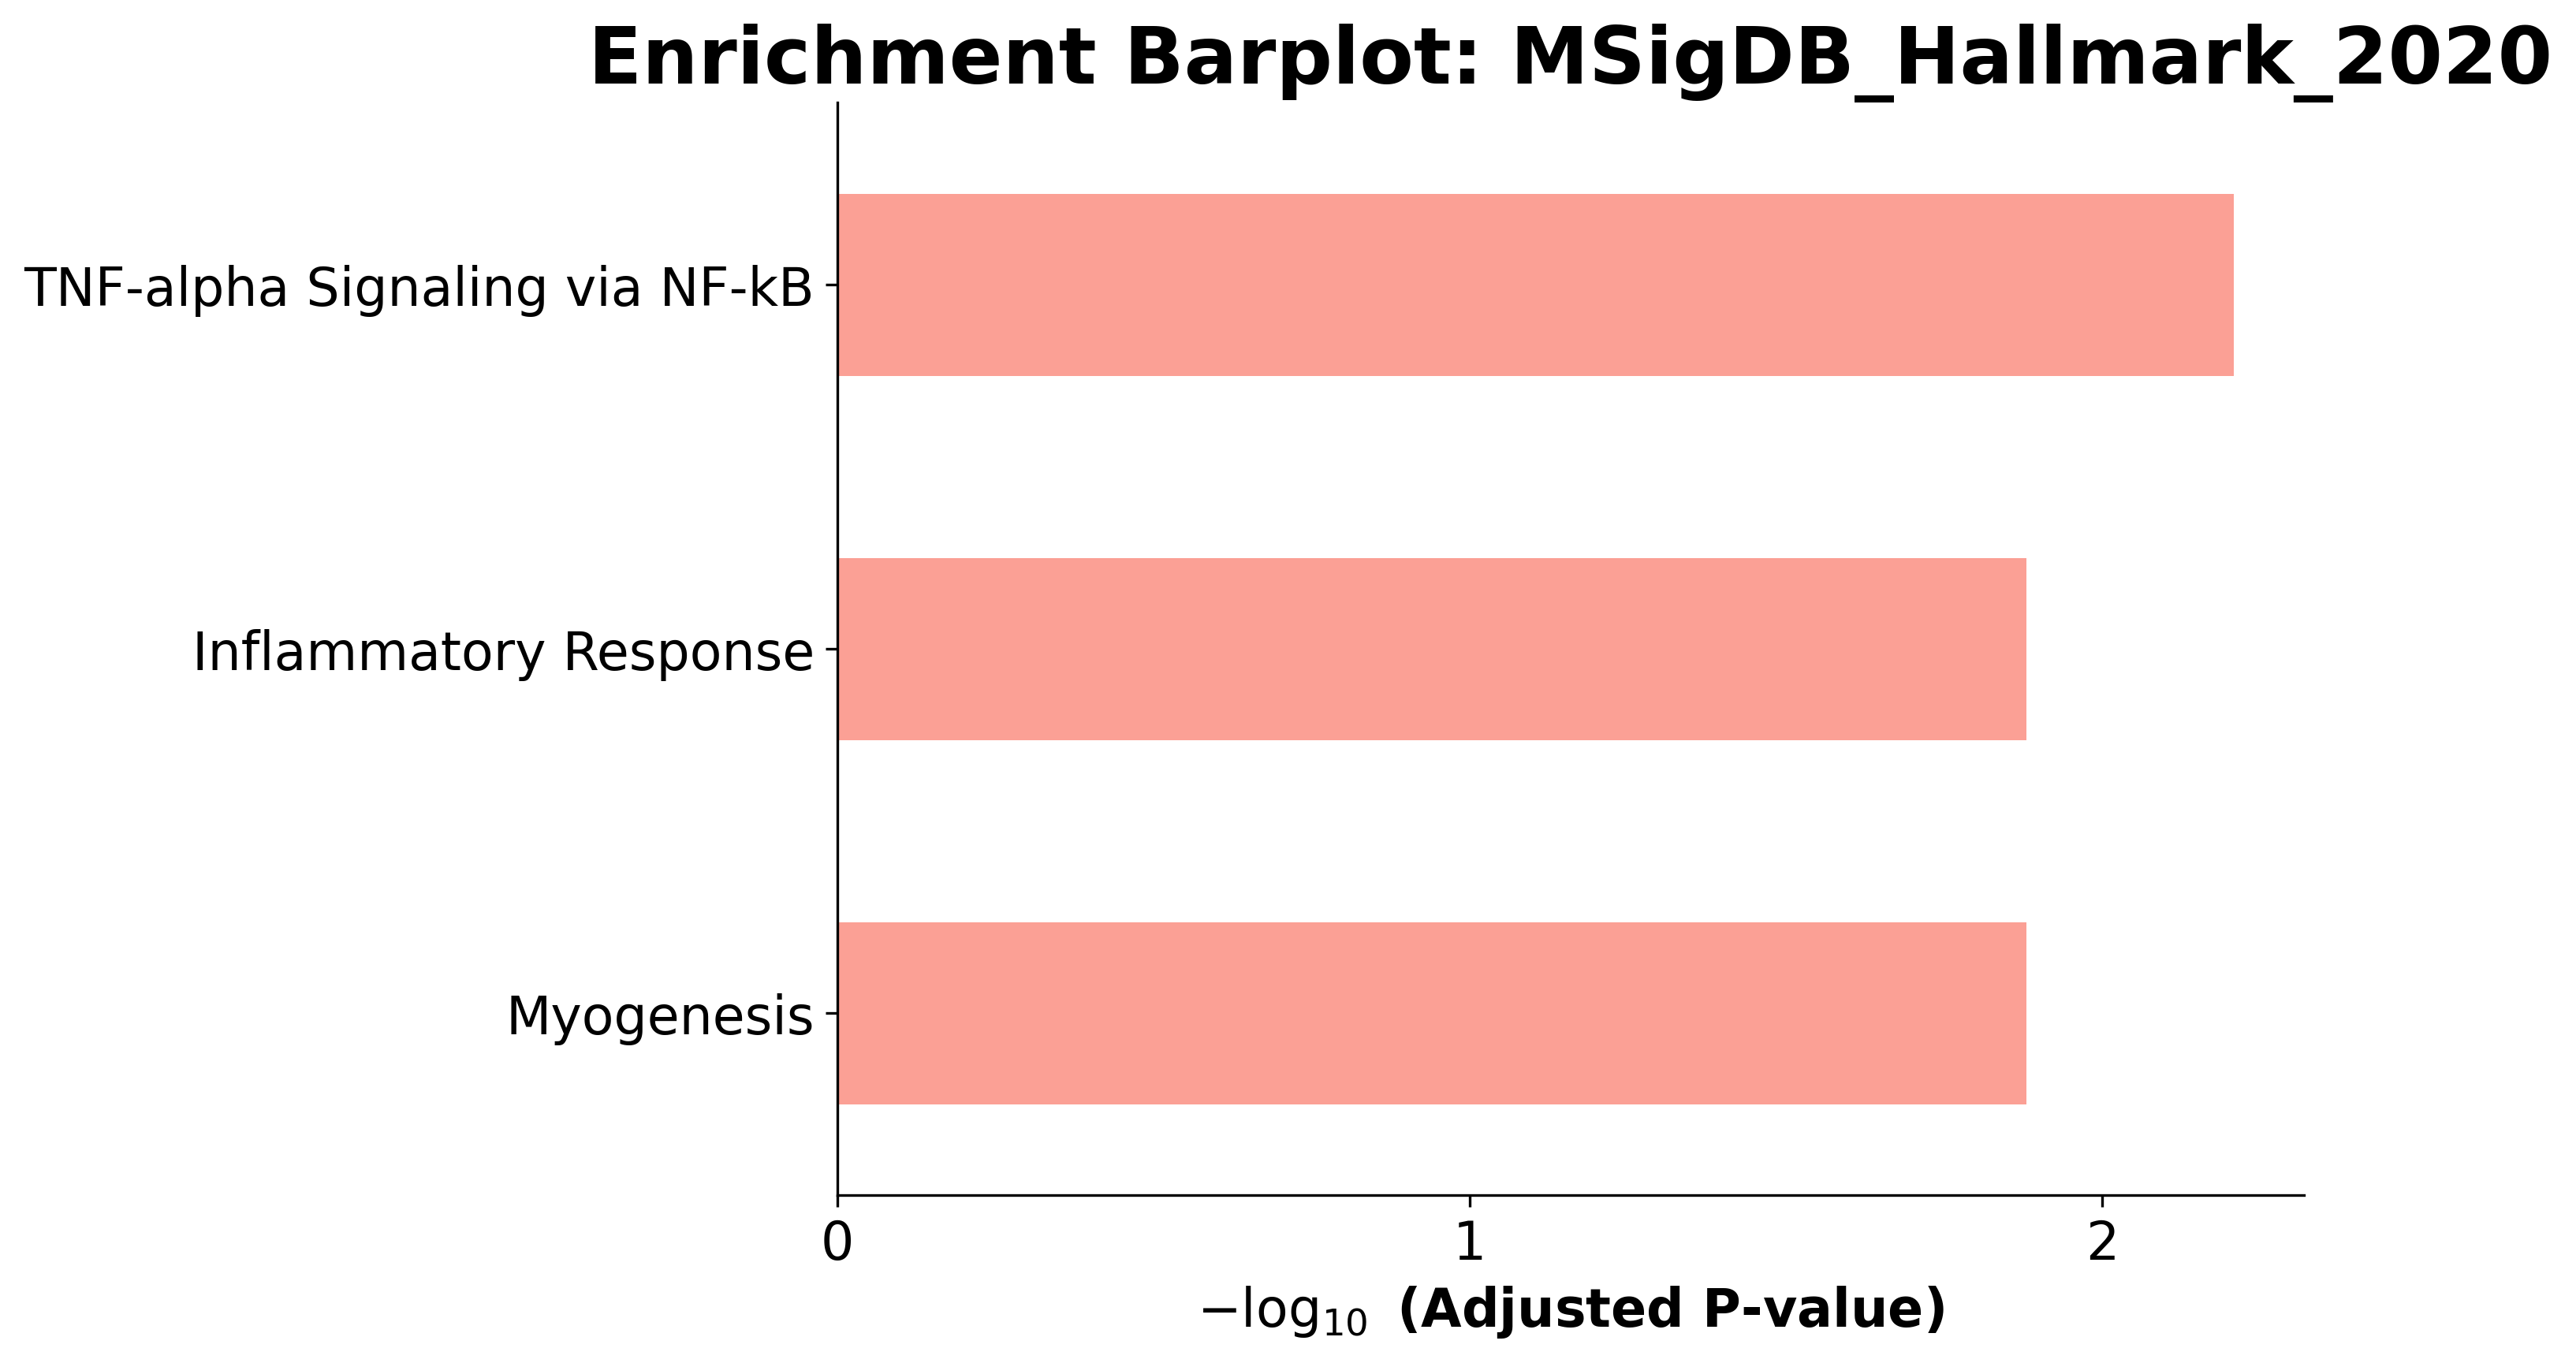

In [10]:
from IPython.display import Image, display

# Ensure FIG and res are available (assuming previous cells have run)
# FIG = '/content/drive/MyDrive/Colon_cancer_project/results/figures/novelty'
# res is the DataFrame from enrichment analysis

if 'res' in locals() and not res.empty:
    gene_sets = res['Gene_set'].unique()
    for gs_name in gene_sets:
        safe_gs_name = gs_name.replace(' ', '_').replace('/', '_')
        dotplot_path = f"{FIG}/{safe_gs_name}_dotplot.png"
        barplot_path = f"{FIG}/{safe_gs_name}_barplot.png"

        print(f"Displaying dotplot for {gs_name}:")
        try:
            display(Image(dotplot_path))
        except FileNotFoundError:
            print(f"Dotplot not found: {dotplot_path}. Please ensure plots have been generated.")

        print(f"Displaying barplot for {gs_name}:")
        try:
            display(Image(barplot_path))
        except FileNotFoundError:
            print(f"Barplot not found: {barplot_path}. Please ensure plots have been generated.")
else:
    print("Enrichment results (res DataFrame) not found or are empty. Cannot display plots.")

Checks if enrichment results (`res`) exist and are non-empty, then iterates over each gene set to display previously saved dotplot and barplot images from the `FIG` directory, handling missing files gracefully.


## Generate Enrichment Plots

### Subtask:
Filter the enrichment results DataFrame by gene set (GO, KEGG, MSigDB) and generate a dotplot and a barplot for each using gseapy's plotting functions, saving them to the figures directory.


## Summary:

### Data Analysis Key Findings
*   For each unique gene set identified in the enrichment results (e.g., GO, KEGG, MSigDB), two types of visualization plots were successfully generated: a dotplot and a barplot.
*   These plots were configured to display the top 20 enriched terms, considering only those with an Adjusted P-value less than 0.05.
*   Dotplots were generated using a `viridis_r` colormap, where darker or more intense colors represent smaller (more significant) p-values.
*   Barplots were generated with bar heights representing the significance based on 'Adjusted P-value' and were colored 'salmon'.
*   All generated plots were saved as PNG image files in the designated figures directory for later review.

### Insights or Next Steps
*   The generated dotplots and barplots provide a clear and concise visual summary of the most significant enrichment results for each gene set, facilitating easy interpretation of the underlying biological processes or pathways.
*   These plots should now be reviewed to identify key biological themes and pathways that are significantly altered or represented in the dataset, informing subsequent hypothesis generation or experimental design.
